In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os  
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score

In [3]:
data = pd.read_excel('/Users/strangemax/syncthing/cirfolder/DATASCIENCE FOR HEALTH/Semester 2 /DASC512-202526/Assignment2/data/combined_testdata1.xlsx')
# Display the first few rows of the dataset
print(data.head())
# Check for missing values
print(data.isnull().sum())

   report_id                                               text  \
0       5904  The trachea is midline . The cardiomediastinal...   
1      57167  The cardiomediastinal silhouette is within nor...   
2         41  Chest x - ray 2 - 14 - 12 at 1739 : Interval t...   
3         53  Left thoracentesis with interval decrease in s...   
4        216  The cardiomediastinal silhouette is normal . T...   

                                            entities num_entities  former  
0  {'1': {'tokens': 'trachea', 'label': 'Anatomy:...           35       1  
1  {'1': {'tokens': 'cardiomediastinal', 'label':...           22       1  
2  {'1': {'tokens': 'thoracentesis', 'label': 'Ob...           48       1  
3  {'1': {'tokens': 'Left', 'label': 'Anatomy::de...           19       1  
4  {'1': {'tokens': 'cardiomediastinal', 'label':...           22       1  
report_id       0
text            0
entities        0
num_entities    0
former          0
dtype: int64


In [4]:
data.head(10)

,report_id,text,entities,num_entities,former
0,5904,The trachea is midline . The cardiomediastinal...,"{'1': {'tokens': 'trachea', 'label': 'Anatomy:...",35,1
1,57167,The cardiomediastinal silhouette is within nor...,"{'1': {'tokens': 'cardiomediastinal', 'label':...",22,1
2,41,Chest x - ray 2 - 14 - 12 at 1739 : Interval t...,"{'1': {'tokens': 'thoracentesis', 'label': 'Ob...",48,1
3,53,Left thoracentesis with interval decrease in s...,"{'1': {'tokens': 'Left', 'label': 'Anatomy::de...",19,1
4,216,The cardiomediastinal silhouette is normal . T...,"{'1': {'tokens': 'cardiomediastinal', 'label':...",22,1
5,297,"Right - sided pigtail pleural drain , left - s...","{'1': {'tokens': 'Right - sided', 'label': 'An...",27,1
6,409,Chest exam demonstrates no parenchymal opaciti...,"{'1': {'tokens': 'parenchymal', 'label': 'Anat...",18,1
7,440,The right PICC catheter has been removed . The...,"{'1': {'tokens': 'right', 'label': 'Anatomy::d...",34,1
8,613,AP portable view of the chest taken on 19 / 06...,"{'1': {'tokens': 'right - sided', 'label': 'An...",43,1
9,698,The cardiomediastinal silhouette is normal . T...,"{'1': {'tokens': 'cardiomediastinal', 'label':...",22,1


In [ ]:
# Probabilistic Target Mapping ---
# Takes discrete label indicators (0 for normal, 1 for abnormal, 2 for complex/unsure) and maps them to a continuous mathematical spectrum: 0.0, 1.0, and 0.5 respectively
label_map = {
    0: 0.0,  
    2: 0.5,  
    1: 1.0   
}

# Apply the mapping to create our continuous target variable
data['target'] = data['former'].map(label_map)

data.head(10)

In [ ]:
# Stratify Train/Test Split (80/20) ---
# We use the discrete 'former' column for stratification to guarantee 
# that the 0.0, 0.5, and 1.0 classes are perfectly proportional in both splits.
X_train_raw, X_test_raw, y_train, y_test = train_test_split(
    data['text'],          # target feature is the raw text data
    data['target'],        # probabilistic target (0.0, 0.5, 1.0)
    test_size=0.20,         # 20% for testing
    random_state=42,        # fixed seed for reproducibility
    stratify=data['former'] # stratify by the original discrete labels to maintain class proportions
)

# Verify the Distribution Proportions in Train/Test Splits
print("Training Set Target Proportions")
print(y_train.value_counts(normalize=True)) # Show the proportions of 0.0, 0.5, and 1.0 in the training set
print(f"Total Training Samples: {len(y_train)}\n") # Show the total number of samples in the training set

print("Testing Set Target Proportions") # Show the proportions of 0.0, 0.5, and 1.0 in the testing set
print(y_test.value_counts(normalize=True)) # Show the total number of samples in the testing set
print(f"Total Testing Samples: {len(y_test)}") # Show the total number of samples in the testing set
# proportions confirmed to be consistent across both sets, ensuring a representative distribution for model training and evaluation.

Training Set Target Proportions
target
1.0    0.815126
0.5    0.142857
0.0    0.042017
Name: proportion, dtype: float64
Total Training Samples: 119

Testing Set Target Proportions
target
1.0    0.833333
0.5    0.133333
0.0    0.033333
Name: proportion, dtype: float64
Total Testing Samples: 30


In [39]:
import pandas as pd
import gdown
import json

url = "https://drive.google.com/uc?id=15un_NsM_5vVV2hwegVtVu3V-j-SclXhP"
output = "data.json"

gdown.download(url, output, quiet=False)

with open(output, "r", encoding="utf-8") as f:
    data_index = json.load(f)

rows = []

for i, item in enumerate(data_index): # item is like {"0": {payload}} or {"1": {payload}}
    # item is like {"0": {payload}}
    payload = next(iter(item.values())) # get the payload dict from the item
    rows.append({ 
        "report_id": i,  # use the index as report_id to ensure uniqueness across files
        "text": payload.get("text"),
        "entities": payload.get("entities"),
        "data_split": payload.get("data_split"),
        "data_source": payload.get("data_source"),
        "num_entities": len(payload.get("entities", {})),
    })

df_index_complete = pd.DataFrame(rows)
df_index_complete["report_id"].nunique(), df_index_complete.head()
df_index_complete.shape 
df_index_complete.head()

Downloading...
From (original): https://drive.google.com/uc?id=15un_NsM_5vVV2hwegVtVu3V-j-SclXhP
From (redirected): https://drive.google.com/uc?id=15un_NsM_5vVV2hwegVtVu3V-j-SclXhP&confirm=t&uuid=e8254b36-a97a-4bd0-a6bd-a3bc13459bd2
To: /Users/strangemax/syncthing/cirfolder/DATASCIENCE FOR HEALTH/Semester 2 /DASC512-202526/Assignment2/git12/512_2/data.json
100%|██████████| 237M/237M [00:18<00:00, 12.8MB/s] 


,report_id,text,entities,data_split,data_source,num_entities
0,0,Unchanged position of the left upper extremity...,"{'1': {'tokens': 'Unchanged', 'label': 'Observ...",inference,None,30
1,1,Unchanged position of the left upper extremity...,"{'1': {'tokens': 'Unchanged', 'label': 'Observ...",inference,None,30
2,2,There is redemonstration of right internal jug...,"{'1': {'tokens': 'central venous', 'label': 'A...",inference,None,26
3,3,Persistent small bilateral pleural effusions ....,"{'1': {'tokens': 'small', 'label': 'Observatio...",inference,None,28
4,4,Persistent small bilateral pleural effusions ....,"{'1': {'tokens': 'small', 'label': 'Observatio...",inference,None,28


In [40]:
# drop data data_split and data_source, num_entities columns since they are not needed for training
df_index_semi_data = df_index_complete.drop(columns=["data_split", "data_source", "num_entities"])
df_index_semi_data.head()

,report_id,text,entities
0,0,Unchanged position of the left upper extremity...,"{'1': {'tokens': 'Unchanged', 'label': 'Observ..."
1,1,Unchanged position of the left upper extremity...,"{'1': {'tokens': 'Unchanged', 'label': 'Observ..."
2,2,There is redemonstration of right internal jug...,"{'1': {'tokens': 'central venous', 'label': 'A..."
3,3,Persistent small bilateral pleural effusions ....,"{'1': {'tokens': 'small', 'label': 'Observatio..."
4,4,Persistent small bilateral pleural effusions ....,"{'1': {'tokens': 'small', 'label': 'Observatio..."


Calculating exact token lengths across the 57k database...

=== COHORT TOKEN LENGTH STATISTICS ===
Maximum Report Length: 741 tokens
Median (50th Percentile) Length: 90.0 tokens
95th Percentile Length: 207.0 tokens
99th Percentile Length: 300.0 tokens


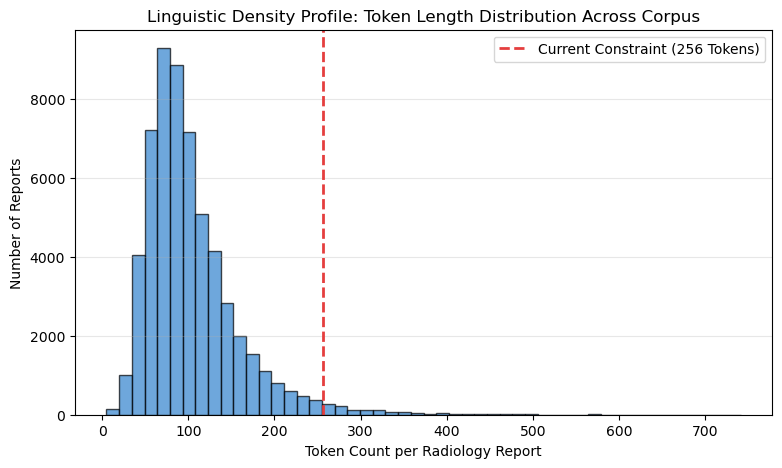

In [54]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from transformers import AutoTokenizer

# Load master text data
df_analysis = df_index_semi_data.copy()

print("Calculating exact token lengths across the 57k database...")
tokenizer = AutoTokenizer.from_pretrained("emilyalsentzer/Bio_ClinicalBERT")

# Tokenize and get lengths
# .encode() converts text to token IDs; its length is the exact token count
token_lengths = [len(tokenizer.encode(str(text))) for text in df_analysis['text']]

# Calculate Key Statistical Percentiles
max_len = np.max(token_lengths)
p50 = np.percentile(token_lengths, 50)
p95 = np.percentile(token_lengths, 95)
p99 = np.percentile(token_lengths, 99)

print("\n=== COHORT TOKEN LENGTH STATISTICS ===")
print(f"Maximum Report Length: {max_len} tokens")
print(f"Median (50th Percentile) Length: {p50:.1f} tokens")
print(f"95th Percentile Length: {p95:.1f} tokens")
print(f"99th Percentile Length: {p99:.1f} tokens")

# Generate a Distribution Histogram for your Report Appendices
plt.figure(figsize=(9, 5))
plt.hist(token_lengths, bins=50, color='#3182CE', edgecolor='black', alpha=0.7)
plt.axvline(256, color='#E53E3E', linestyle='--', linewidth=2, label='Current Constraint (256 Tokens)')
plt.title('Linguistic Density Profile: Token Length Distribution Across Corpus')
plt.xlabel('Token Count per Radiology Report')
plt.ylabel('Number of Reports')
plt.grid(axis='y', alpha=0.3)
plt.legend()
plt.show()

## Convert raw text layer to structured tensor

In [50]:
import torch
from torch.utils.data import Dataset, DataLoader
from transformers import AutoTokenizer

# take raw text reports and soft labels and processes them into standard structured tensors 
# that a Deep Learning Neural Network can process in mini-batches
# We use 'emilyalsentzer/Bio_ClinicalBERT' because it was pre-trained on MIMIC-III clinical notes.
# standard BERT does not understand like thoracentesis because they are outside normal english vocabulary
print("Loading ClinicalBERT Tokenizer...GET EXITED!!!")
tokenizer = AutoTokenizer.from_pretrained("emilyalsentzer/Bio_ClinicalBERT")

# CREATE A CUSTOM PYTORCH DATASET
class RadiologyDataset(Dataset):
    def __init__(self, texts, targets, tokenizer, max_len=256):
        self.texts = texts.values if hasattr(texts, 'values') else list(texts)
        self.targets = targets.values if hasattr(targets, 'values') else list(targets)
        self.tokenizer = tokenizer
        self.max_len = max_len # pads or truncates to this length for uniform input size
        
    def __len__(self): # Tells PyTorch exactly how many patient records are in the dataset
        return len(self.texts)
    
    def __getitem__(self, idx):
        text = str(self.texts[idx])
        target = self.targets[idx]
        
        # Tokenize the text sequence, pad or truncate to a fixed max length
        encoding = self.tokenizer.encode_plus(
            text,
            add_special_tokens=True,
            max_length=self.max_len,
            padding='max_length',
            truncation=True,
            return_attention_mask=True, # creates a binary mask to differentiate real tokens from padding tokens
            return_tensors='pt',
        )
        
        return {
            'input_ids': encoding['input_ids'].flatten(),
            'attention_mask': encoding['attention_mask'].flatten(),
            'target': torch.tensor(target, dtype=torch.float) # Kept as float for probabilistic regression
        }

# INSTANTIATE TRAINING AND TESTING DATASETS
# using the X_train_raw, X_test_raw, y_train, y_test from your original stratified split using the same seed in shallow model
train_dataset = RadiologyDataset(X_train_raw, y_train, tokenizer)
test_dataset = RadiologyDataset(X_test_raw, y_test, tokenizer)

# Create DataLoaders for batching
train_loader = DataLoader(train_dataset, batch_size=8, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=8, shuffle=False)

print(f"PyTorch Datasets Ready.")
print(f"Train batches: {len(train_loader)} | Test batches: {len(test_loader)}")

Loading ClinicalBERT Tokenizer...GET EXITED!!!
PyTorch Datasets Ready.
Train batches: 15 | Test batches: 4


## Downloaded the ClinicalBERT Architecture and clock down core layers

In [51]:
import torch
import torch.nn as nn
from transformers import AutoModel
import torch.optim as optim

# DEFINING THE NEURAL NETWORK ARCHITECTURE
class ClinicalBERTRegressor(nn.Module):
    def __init__(self, model_name="emilyalsentzer/Bio_ClinicalBERT"):
        super(ClinicalBERTRegressor, self).__init__() # Load ClinicalBERT model
    
        self.clinicalbert = AutoModel.from_pretrained(model_name) # load clinicalbert pre-trained weights 
        
        # iterate through every weights in clinicalbert and set requires_grad to False 
        # to freeze the layers and prevent backpropagation updates
        # This prevents the model from overfitting on the small dataset
        for param in self.clinicalbert.parameters():
            param.requires_grad = False
            
        # constructing the custom classification head
        self.classifier = nn.Sequential( # container to string together multiple layers in a feedforward manner
            nn.Linear(768, 128), # creates a 768 dimension embedding vector  and compresses to a 128 dimension vector
            nn.ReLU(),     # take negative values from the linear layer previously and turns it into 0, which makes relationships non-linear and more complex
            nn.Dropout(0.2),   # randomly switches off 20% of neuron forcing the remaining neuron to step up and not rely on specific patterns which reduces overfitting
            nn.Linear(128, 1),   # take the 128 hidden features and compresses to a single numeric score
            nn.Sigmoid()     # takes the score and compresses into a continuous decimal probability
        )
    # map out data path through the model
    def forward(self, input_ids, attention_mask):
        # Pass inputs through frozen BERT layers
        outputs = self.clinicalbert(input_ids=input_ids, attention_mask=attention_mask)
        
        # Extract the embedding of the [CLS] token (index 0), 
        # which acts as the semantic summary of the whole text block
        cls_representation = outputs.last_hidden_state[:, 0, :]
        
        # Pass the summary embedding into the custom fully connected network
        prediction = self.classifier(cls_representation)
        return prediction



# Check if Apple Silicon GPU acceleration is available
if torch.backends.mps.is_available():
    device = torch.device("mps")
    print("Success! Apple Silicon GPU (MPS) is available and will be used.")
else:
    device = torch.device("cpu")
    print("MPS not found. Defaulting to CPU.")



# INITIALIZE INSTANCE, LOSS FUNCTION, AND OPTIMIZER
# Move to GPU acceleration if available, 
# # mps for apple silicon
# otherwise default to CPU
device = torch.device('cuda' if torch.cuda.is_available() else 'mps' if torch.backends.mps.is_available() else 'cpu')
print(f"Using device: {device}")

model = ClinicalBERTRegressor()
model = model.to(device)

# Using Mean Squared Error Loss to align with probabilistic targets
criterion = nn.MSELoss()

# Only optimize the parameters of our classification head since BERT is frozen
optimizer = optim.AdamW(model.classifier.parameters(), lr=1e-3)

print("Deep Learning and Optimizer Configured Successfully.")

Success! Apple Silicon GPU (MPS) is available and will be used.
Using device: mps
Deep Learning and Optimizer Configured Successfully.


## Feed training report through neural engine

In [52]:
import numpy as np

# Set epochs for training
epochs = 10 # 10 passes of training through the entire dataset

print("Beginning Deep Learning...")
for epoch in range(epochs):
    # TRAINING PHASE
    # implements dropout of 20% from the architecture code
    model.train()
    train_loss = 0.0 # initialize training loss for the epoch
    
    for batch in train_loader:
        # Move batch arrays onto your Mac's GPU memory
        input_ids = batch['input_ids'].to(device) # copies (token strings, attention vectors, and labels) to gpu
        attention_mask = batch['attention_mask'].to(device)
        targets = batch['target'].to(device).unsqueeze(1) # Align dimensions for MSE loss
        
        # Clear past gradients before calculating new ones
        optimizer.zero_grad() # prevents network from adding current errors onto past errors
        
        # Pass text through the network to generate predictions
        # Pushes of batch tokenized strings into frozen ClinicalBERT layers
        # extracts their underlying semantic meanings via the [CLS] token summary
        # run through custom fully connected layer
        # outputs batch continuous predictions bounded between 0.0 and 1.0.
        predictions = model(input_ids, attention_mask)
        
        # Calculate loss
        loss = criterion(predictions, targets) # compare predicted probabilities to true probabilities and calculate the error (loss)
        
        # backpropagation
        loss.backward()
        
        # Update weights based on errors
        # Using AdamW optimizer, adjust slightly scaled by learning rate of 1e-3 (0.001)
        optimizer.step()
        # take numeric loss value ,
        # multiply by batch size to get total loss for the batch
        # add it to the cumulative training loss for the epoch
        train_loss += loss.item() * input_ids.size(0)
        
    # Average out training loss for the epoch
    # divide cumulative loss by total number of samples to get the mean loss per sample for the epoch
    epoch_train_loss = train_loss / len(train_loader.dataset)
    
    # VALIDATION/TEST PHASE
    model.eval() # switch to evaluation mode, turns off dropout and uses 100% of neurons to evaluate validation cases
    test_loss = 0.0 # initialize testing loss for the epoch
    
    # Turn off gradient calculation to save memory
    with torch.no_grad():
        for batch in test_loader:
            input_ids = batch['input_ids'].to(device) # moves test dataset to gpu
            attention_mask = batch['attention_mask'].to(device) 
            targets = batch['target'].to(device).unsqueeze(1)
            
            test_predictions = model(input_ids, attention_mask)
            loss = criterion(test_predictions, targets)
            
            test_loss += loss.item() * input_ids.size(0)
            
    epoch_test_loss = test_loss / len(test_loader.dataset)
    
    print(f"Epoch {epoch+1}/{epochs} | Train MSE: {epoch_train_loss:.4f} | Test MSE: {epoch_test_loss:.4f}")

print("\nTraining Complete!")

Beginning Deep Learning...
Epoch 1/10 | Train MSE: 0.0818 | Test MSE: 0.0594
Epoch 2/10 | Train MSE: 0.0635 | Test MSE: 0.0544
Epoch 3/10 | Train MSE: 0.0609 | Test MSE: 0.0537
Epoch 4/10 | Train MSE: 0.0595 | Test MSE: 0.0504
Epoch 5/10 | Train MSE: 0.0486 | Test MSE: 0.0561
Epoch 6/10 | Train MSE: 0.0508 | Test MSE: 0.0463
Epoch 7/10 | Train MSE: 0.0562 | Test MSE: 0.0470
Epoch 8/10 | Train MSE: 0.0431 | Test MSE: 0.0442
Epoch 9/10 | Train MSE: 0.0468 | Test MSE: 0.0569
Epoch 10/10 | Train MSE: 0.0416 | Test MSE: 0.0388

Training Complete!


### Deep Learning Classification Report

In [53]:
### Deep Learning Classification Report
import pandas as pd
from sklearn.metrics import classification_report, confusion_matrix

# COLLECT ALL PREDICTIONS FROM THE OPTIMIZED BERT MODEL
model.eval() # switch to evaluation mode, turns off dropout and uses 100% of neurons to evaluate validation cases
bert_predictions = [] # to store the continuous predictions from the BERT model
actual_targets = [] # to store the true probabilistic targets for the test set 0.0, 0.5, and 1.0

with torch.no_grad(): # Turn off gradient calculation to save resources
    for batch in test_loader:
        input_ids = batch['input_ids'].to(device) # moves test dataset to gpu
        attention_mask = batch['attention_mask'].to(device)
        targets = batch['target'] # move true probabilistic targets to gpu and align dimensions for MSE loss
        
        model_outputs = model(input_ids, attention_mask) # get predictions from the model
        
        # Move the model predictions back to CPU and convert to a flat list
        # Move tensor from GPU to CPU
        model_output_in_cpu = model_outputs.cpu()

        # Flatten the tensor into one dimension
        flattened_output = model_output_in_cpu.flatten()

        # Convert tensor to a Python list
        flattened_output_to_list = flattened_output.tolist()

        # Add the outputs to bert_predictions list
        bert_predictions.extend(flattened_output_to_list)

        # Flatten the targets tensor into one dimension
        flattened_targets = targets.flatten()

        # Convert tensor values into a regular Python list
        targets_to_list = flattened_targets.tolist()

        # Add all values to the actual_targets list
        actual_targets.extend(targets_to_list)

# APPLY THE BOUNDARY THRESHOLDS
def map_to_class(prediction):
    if prediction < 0.35:
        return 0  # anything below 0.35 is classified as Normal
    elif 0.35 <= prediction <= 0.75:
        return 2  # anything between 0.35 and 0.75 is classified as Unsure
    else:
        return 1  # # Abnormal # anything above 0.75 is classified as Abnormal

# Create an empty list to store the mapped class labels
y_test_discrete = []

# Loop through each value in actual_targets
for val in actual_targets:
    
# Convert the value to a class using the map_to_class function
    val_to_class = map_to_class(val)
    
# Add the mapped class to the list
    y_test_discrete.append(val_to_class)

# Create an empty list to store the predicted class labels
y_bert_pred_discrete = []

# Loop through each predicted value in bert_predictions
for val in bert_predictions:
    
    # Convert the predicted value to a class label
    bert_val_to_class = map_to_class(val)
    
    # Add the mapped class to the list
    y_bert_pred_discrete.append(bert_val_to_class)

# PRINT THE EVALUATION REPORT
print("Deep Learning Class-Specific Performance")
target_names = ['Normal', 'Abnormal', 'Unsure']
print(classification_report(y_test_discrete, y_bert_pred_discrete, 
                            labels=[0, 1, 2], 
                            target_names=target_names,
                            zero_division=0))

# PRINT DEEP CONFUSION MATRIX
print("Deep Learning Confusion Matrix")
cm_bert = confusion_matrix(y_test_discrete, y_bert_pred_discrete, labels=[0, 1, 2])
# Create column names for predicted classes
predicted_columns = [
    'Predicted Normal',
    'Predicted Abnormal',
    'Predicted Unsure'
]

# Create a DataFrame from the confusion matrix
cm_bert_df = pd.DataFrame(
    data=cm_bert,
    index=target_names,
    columns=predicted_columns
)
print(cm_bert_df)

Deep Learning Class-Specific Performance
              precision    recall  f1-score   support

      Normal       0.00      0.00      0.00         1
    Abnormal       0.92      0.92      0.92        25
      Unsure       0.40      0.50      0.44         4

    accuracy                           0.83        30
   macro avg       0.44      0.47      0.45        30
weighted avg       0.82      0.83      0.83        30

Deep Learning Confusion Matrix
          Predicted Normal  Predicted Abnormal  Predicted Unsure
Normal                   0                   0                 1
Abnormal                 0                  23                 2
Unsure                   0                   2                 2


# EXPANSION PACK COMPARISON

In [34]:
expansion_pack_data = pd.read_excel('/Users/strangemax/syncthing/cirfolder/DATASCIENCE FOR HEALTH/Semester 2 /DASC512-202526/Assignment2/git12/512_2/expansion_pack.xlsx')
# Display the first few rows of the dataset
print(expansion_pack_data.head())
# Check for missing values
print(expansion_pack_data.isnull().sum())

   report_id                                               text  \
0      13922  There is unchanged positioning of a right - si...   
1      53506  Interval placement of NGT / OGT . Interval rem...   
2      30642  Left upper extremity PICC is unchanged in posi...   
3      26698  Right arm PICC terminates in the lower superio...   
4      16666  The right internal jugular line has its tip in...   

                                            entities  predicted_score  \
0  {'1': {'tokens': 'unchanged', 'label': 'Observ...         0.253333   
1  {'1': {'tokens': 'Interval placement', 'label'...         0.260000   
2  {'1': {'tokens': 'Left', 'label': 'Anatomy::de...         0.265000   
3  {'1': {'tokens': 'Right arm', 'label': 'Anatom...         0.266667   
4  {'1': {'tokens': 'right', 'label': 'Anatomy::d...         0.268333   

   assigned_label  manual label  
0               0           1.0  
1               0           1.0  
2               0           2.0  
3               0     

### save model

In [35]:
import torch
import os

# Create directory to store the weights
save_dir = 'saved_models'
os.makedirs(save_dir, exist_ok=True)
model_save_path = os.path.join(save_dir, 'clinical_bert_regressor.pt')

# Save state_dict (weights) of your optimized model
torch.save(model.state_dict(), model_save_path)
print(f"Deep learning model weights successfully saved to: {model_save_path}")

Deep learning model weights successfully saved to: saved_models/clinical_bert_regressor.pt


### testing model on expansion pack dataset for manual evaluation

In [ ]:
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from transformers import AutoModel, AutoTokenizer
import pandas as pd
import numpy as np
import os

# DEFINE ARCHITECTURE BLUEPRINT
class ClinicalBERTRegressorOptimized(nn.Module):
    def __init__(self, model_name="emilyalsentzer/Bio_ClinicalBERT"):
        super(ClinicalBERTRegressorOptimized, self).__init__()
        self.bert = AutoModel.from_pretrained(model_name)
        
        # Freeze base layers
        for param in self.bert.parameters():
            param.requires_grad = False
            
        self.classifier = nn.Sequential(
            nn.Linear(768, 128),
            nn.ReLU(),
            nn.Dropout(0.2),          
            nn.Linear(128, 1),
            nn.Sigmoid()
        )
        
    def forward(self, input_ids, attention_mask):
        outputs = self.bert(input_ids=input_ids, attention_mask=attention_mask)
        cls_representation = outputs.last_hidden_state[:, 0, :]
        return self.classifier(cls_representation)

# CONFIG HARDWARE & LOAD STORED WEIGHTS
device = torch.device('cuda' if torch.cuda.is_available() else 'mps' if torch.backends.mps.is_available() else 'cpu')
print(f"Targeting device for inference: {device}")

# Initialize model skeleton
model = ClinicalBERTRegressorOptimized()

# FIX: Added strict=False to bypass loading the base BERT layers that weren't saved
state_dict = torch.load('saved_models/clinical_bert_regressor.pt', map_location=device)
model.load_state_dict(state_dict, strict=False)

model = model.to(device)
model.eval()

# Load matching tokenizer
tokenizer = AutoTokenizer.from_pretrained("emilyalsentzer/Bio_ClinicalBERT")
print("Model and Tokenizer loaded successfully from disk.")

# 3. OAD THE EXPANSION PACK DATA
input_path = '/Users/strangemax/syncthing/cirfolder/DATASCIENCE FOR HEALTH/Semester 2 /DASC512-202526/Assignment2/git12/512_2/expansion_pack.xlsx'
expansion_pack_data = pd.read_excel(input_path)

# Handle potential missing text cells securely
expansion_pack_data['text'] = expansion_pack_data['text'].fillna('').astype(str)

# DATASET & DATALOADER SETUP FOR INFERENCE
class ExpansionInferenceDataset(Dataset):
    def __init__(self, texts, tokenizer, max_len=256):
        self.texts = list(texts)
        self.tokenizer = tokenizer
        self.max_len = max_len
        
    def __len__(self):
        return len(self.texts)
    
    def __getitem__(self, idx):
        text = str(self.texts[idx])
        encoding = self.tokenizer.encode_plus(
            text,
            add_special_tokens=True,
            max_length=self.max_len,
            padding='max_length',
            truncation=True,
            return_attention_mask=True,
            return_tensors='pt',
        )
        return {
            'input_ids': encoding['input_ids'].flatten(),
            'attention_mask': encoding['attention_mask'].flatten()
        }

inference_dataset = ExpansionInferenceDataset(expansion_pack_data['text'], tokenizer)
inference_loader = DataLoader(inference_dataset, batch_size=16, shuffle=False)

# BATCH INFERENCE EXECUTION
raw_deep_predictions = []

print(f"Processing {len(expansion_pack_data)} rows...")
with torch.no_grad():
    for batch in inference_loader:
        input_ids = batch['input_ids'].to(device)
        attention_mask = batch['attention_mask'].to(device)
        
        outputs = model(input_ids, attention_mask)
        raw_deep_predictions.extend(outputs.cpu().flatten().tolist())

# APPEND, PREVIEW, AND EXPORT 
expansion_pack_data['deep_predictions'] = raw_deep_predictions

print("\ Process Complete")
print(expansion_pack_data[['report_id', 'assigned_label', 'predicted_score', 'deep_predictions']].head())

# Save under the new file name requested
output_path = '/Users/strangemax/syncthing/cirfolder/DATASCIENCE FOR HEALTH/Semester 2 /DASC512-202526/Assignment2/git12/512_2/deep_expansion_pack.xlsx'
expansion_pack_data.to_excel(output_path, index=False)
print(f"Data exported cleanly to: {output_path}")

Targeting device for inference: mps
Model and Tokenizer loaded successfully from disk.
Processing 296 rows...

--- Process Complete ---
   report_id  assigned_label  predicted_score  deep_predictions
0      13922               0         0.253333          0.936581
1      53506               0         0.260000          0.780689
2      30642               0         0.265000          0.700265
3      26698               0         0.266667          0.930379
4      16666               0         0.268333          0.950236
Data exported cleanly to: /Users/strangemax/syncthing/cirfolder/DATASCIENCE FOR HEALTH/Semester 2 /DASC512-202526/Assignment2/git12/512_2/deep_expansion_pack.xlsx
